In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

In [4]:
titanic = sns.load_dataset("titanic")
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [5]:
features = ["pclass","sex","fare","embarked","age"]

In [6]:
imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

titanic.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [7]:
le = LabelEncoder()
titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

In [8]:
X = titanic[features]
Y = titanic["survived"]

X_train,X_test,Y_train,Y_test = train_test_split(
    X,Y,
    test_size=0.2,
    random_state=42
)



In [9]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train,Y_train)

Y_pred = model.predict(X_test)

In [10]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report

print(classification_report(Y_test,Y_pred))
print(confusion_matrix(Y_test,Y_pred))

              precision    recall  f1-score   support

           0       0.82      0.78      0.80       105
           1       0.71      0.76      0.73        74

    accuracy                           0.77       179
   macro avg       0.76      0.77      0.77       179
weighted avg       0.77      0.77      0.77       179

[[82 23]
 [18 56]]


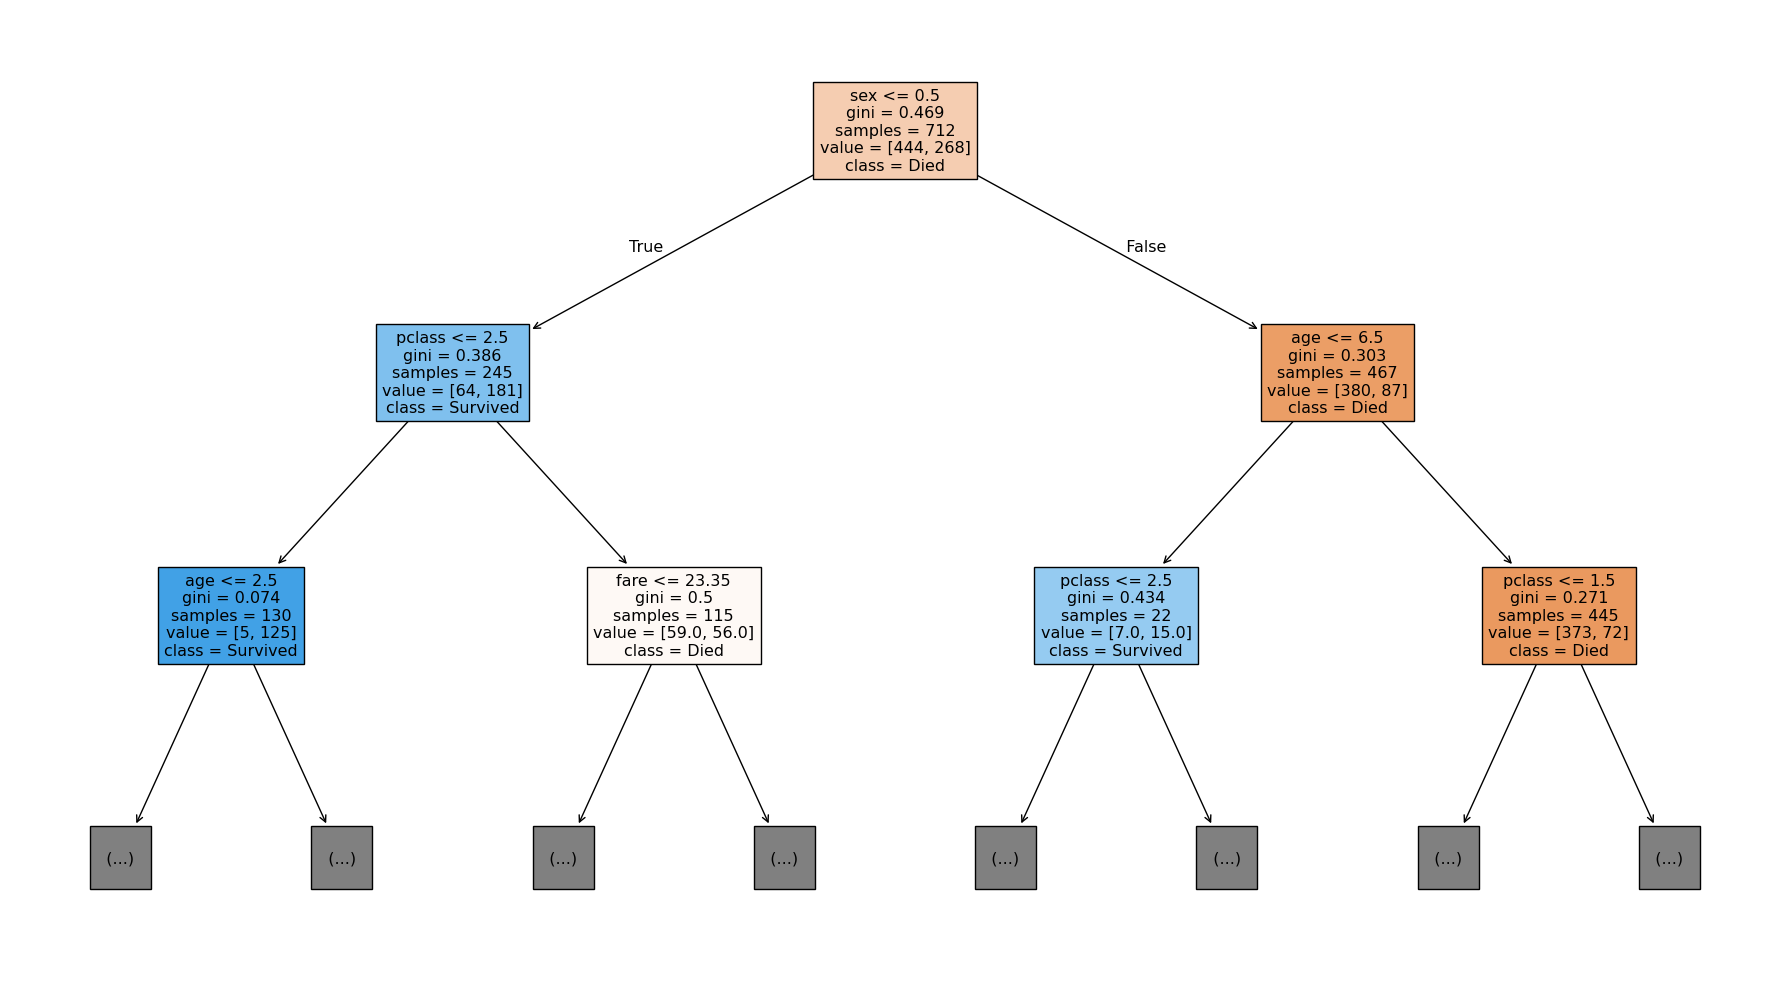

In [11]:
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died","Survived"],
    filled=True,
    max_depth=2
)
plt.tight_layout()
plt.show()

# Pruning

In [12]:

max_depths = [2,3,4,5,6,7,8,9,10]

for i in max_depths:
    model = DecisionTreeClassifier(max_depth=i)
    model.fit(X_train,Y_train)

    Y_pred = model.predict(X_test)
    print("Max depth= ",i)
    print(accuracy_score(Y_test,Y_pred))
    print()


Max depth=  2
0.7653631284916201

Max depth=  3
0.7988826815642458

Max depth=  4
0.7988826815642458

Max depth=  5
0.7988826815642458

Max depth=  6
0.8044692737430168

Max depth=  7
0.7988826815642458

Max depth=  8
0.7932960893854749

Max depth=  9
0.7821229050279329

Max depth=  10
0.7988826815642458



# Now for max_depth = 8

In [13]:
min_sample_splits = [i for i in range(5,35,5)]
for i in min_sample_splits:
    model = DecisionTreeClassifier(
        max_depth=8,
        min_samples_split=i
    )

    model.fit(X_train,Y_train)
    Y_pred = model.predict(X_test)
    print(F"{i}: {accuracy_score(Y_test,Y_pred)}")

5: 0.8100558659217877
10: 0.8379888268156425
15: 0.8379888268156425
20: 0.8379888268156425
25: 0.8212290502793296
30: 0.8100558659217877


# Post Pruning

In [14]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train,Y_train)
Y_pred = full_tree.predict(X_test)

In [15]:
path = full_tree.cost_complexity_pruning_path(X_train,Y_train)
ccp_alphas = path.ccp_alphas
print(ccp_alphas)

[0.00000000e+00 0.00000000e+00 6.68806849e-05 1.45921494e-04
 1.84428555e-04 2.00642055e-04 2.34082397e-04 2.34082397e-04
 3.51123596e-04 4.68164794e-04 4.68164794e-04 5.61797753e-04
 6.24219725e-04 6.67991230e-04 7.02247191e-04 7.02247191e-04
 8.19288390e-04 8.19288390e-04 8.32292967e-04 8.42696629e-04
 8.42696629e-04 8.42696629e-04 8.94231048e-04 8.99610781e-04
 9.24769963e-04 9.36329588e-04 9.36329588e-04 9.36329588e-04
 9.88347898e-04 1.00253471e-03 1.05337079e-03 1.07400895e-03
 1.08038029e-03 1.11865144e-03 1.12359551e-03 1.12359551e-03
 1.13139825e-03 1.17041199e-03 1.18841832e-03 1.22566125e-03
 1.22893258e-03 1.22893258e-03 1.24361593e-03 1.24843945e-03
 1.27565833e-03 1.30996111e-03 1.33761370e-03 1.37044603e-03
 1.46301498e-03 1.47927070e-03 1.51142557e-03 1.54072312e-03
 1.56675436e-03 1.60434338e-03 1.66892062e-03 1.76144762e-03
 1.86751451e-03 2.10674157e-03 2.34082397e-03 2.41226470e-03
 2.64273538e-03 2.69412911e-03 3.43770913e-03 3.56327570e-03
 5.47433606e-03 9.055400

In [16]:
tree = []
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42,ccp_alpha=alpha)
    model.fit(X_train,Y_train)
    acc = model.score(X_test,Y_test)
    tree.append((model,alpha))


In [17]:
best_acc = 0
best_alpha = 0

for model,alpha in tree:
    curr_accuracy = model.score(X_test,Y_test)
    if(curr_accuracy>best_acc):
        best_acc = curr_accuracy
        best_alpha = alpha
print(best_alpha,best_acc)

0.0015407231242023183 0.8379888268156425


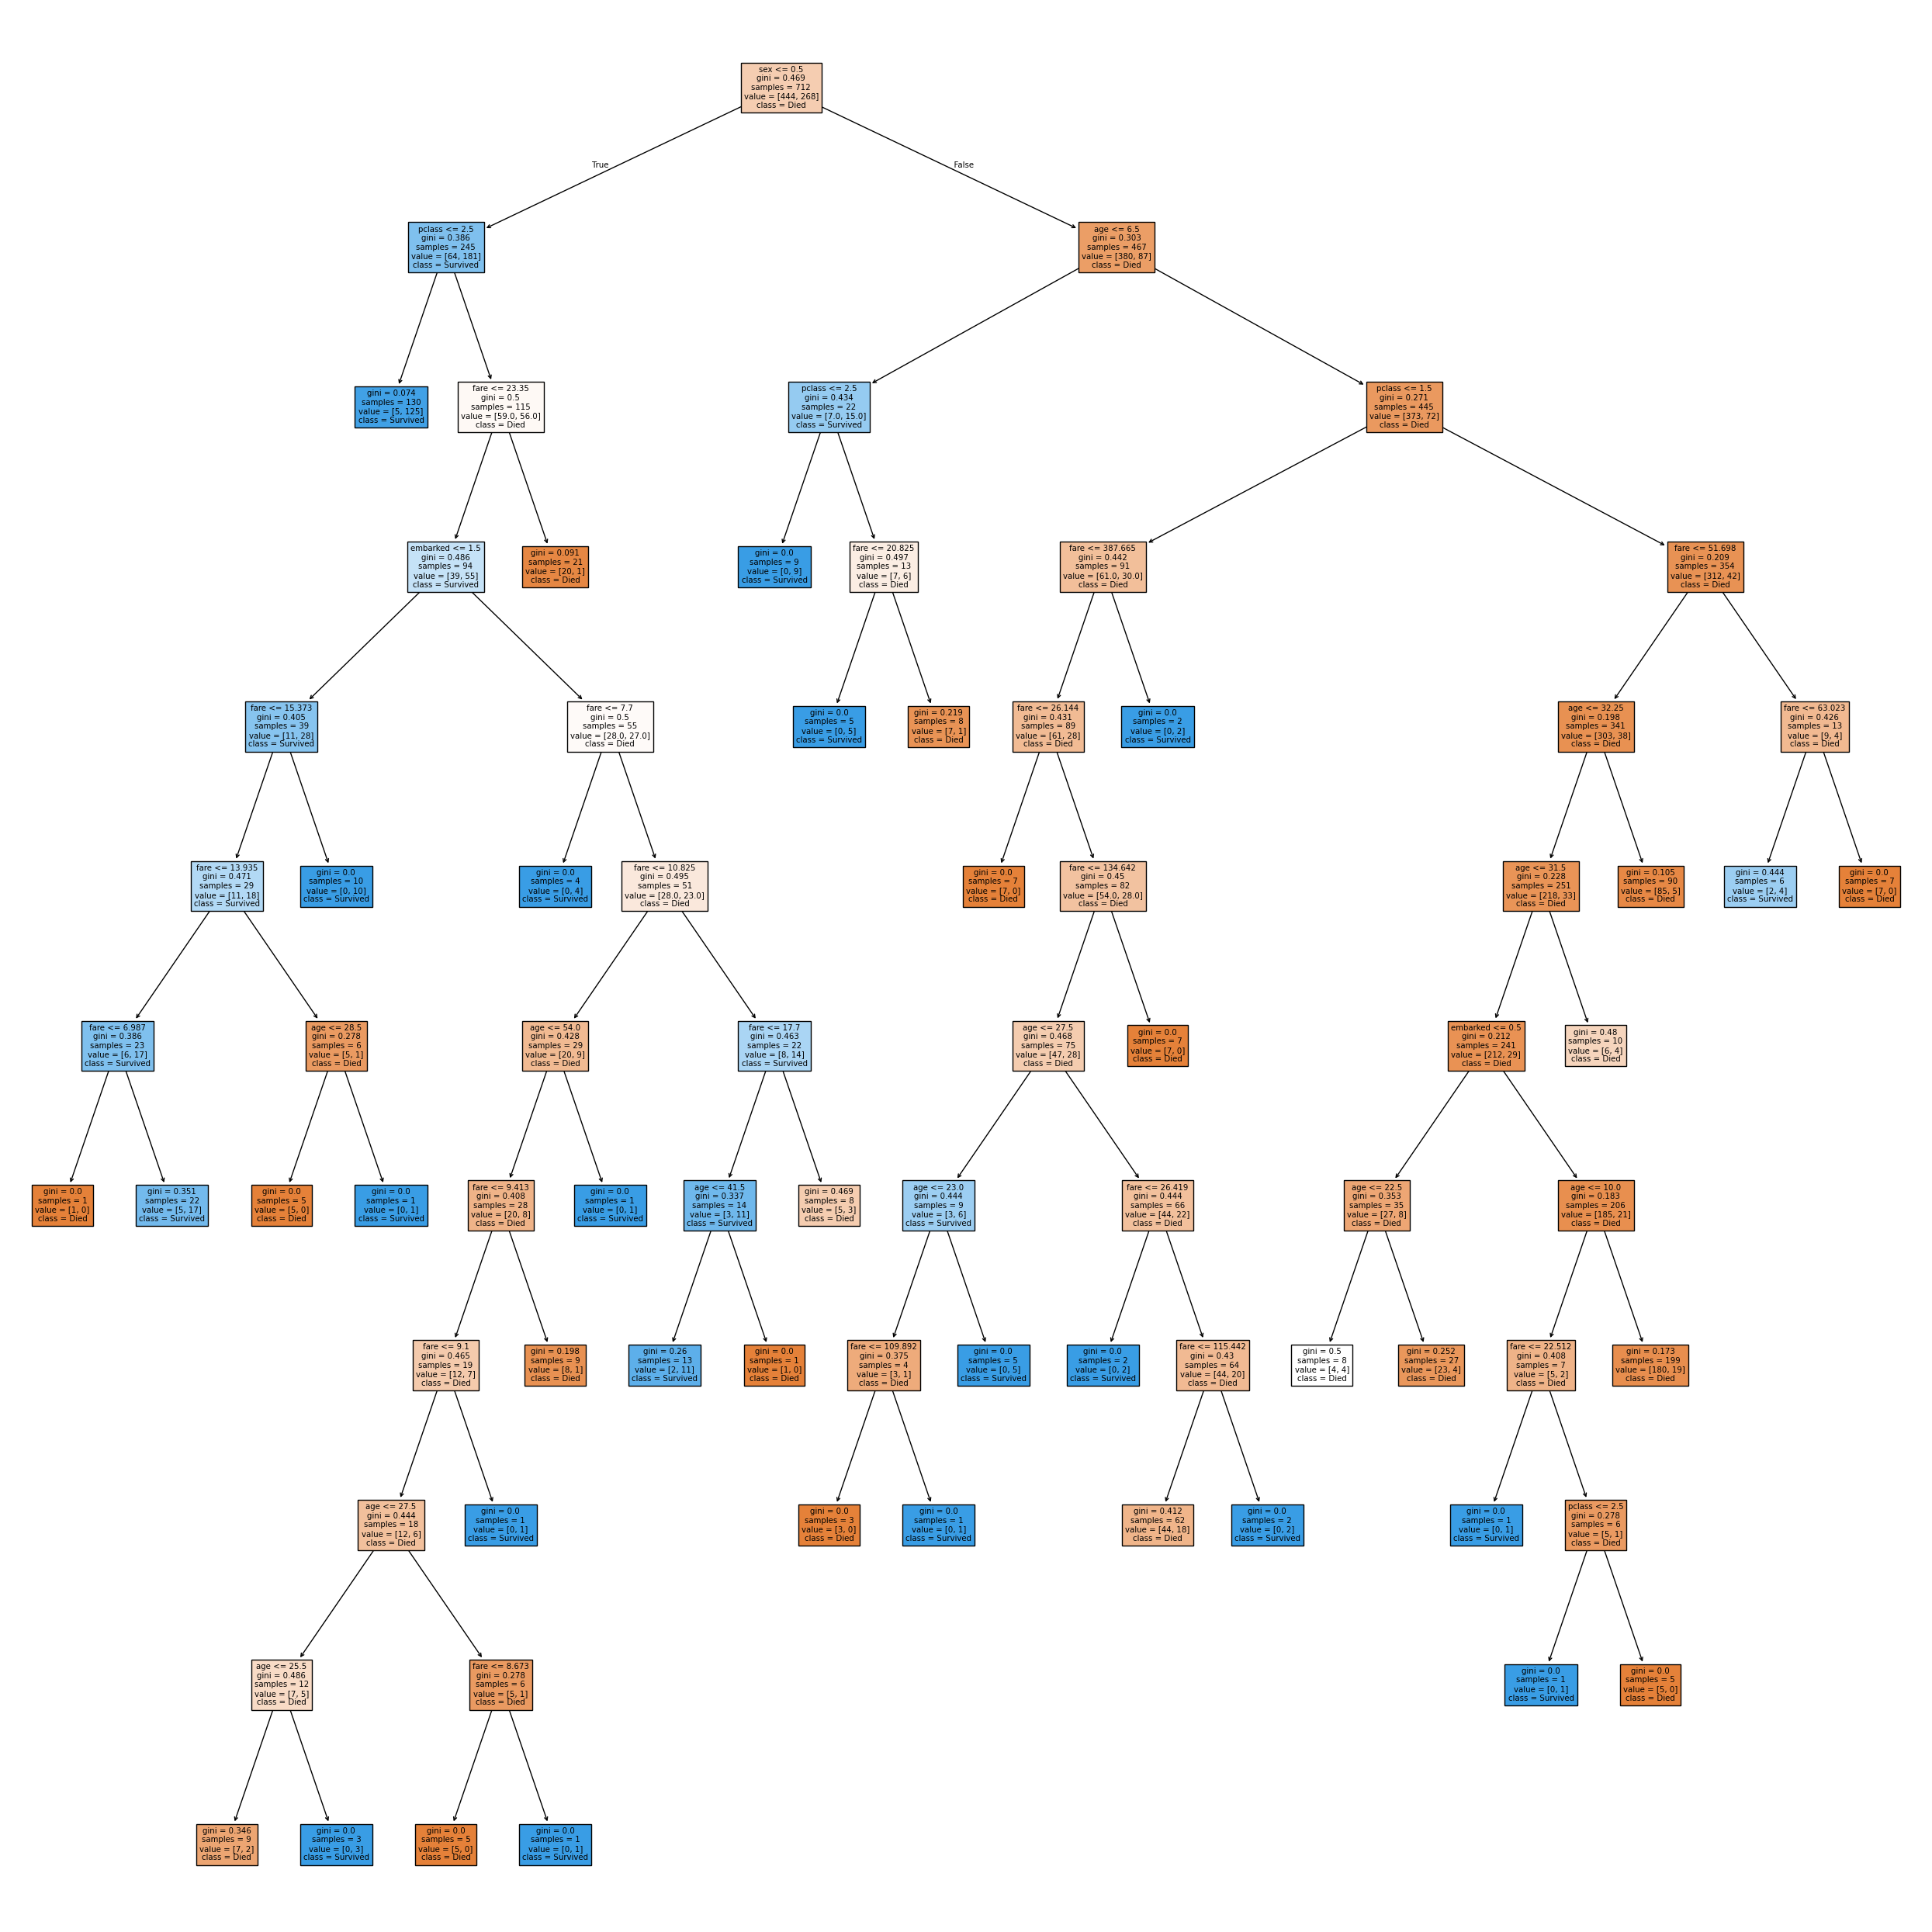

In [18]:
best_model = DecisionTreeClassifier(random_state=42,ccp_alpha=best_alpha)
best_model.fit(X_train,Y_train)
Y_pred = best_model.predict(X_test)
plt.figure(figsize=(25,25))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["Died","Survived"],
    filled=True
)
plt.tight_layout()

In [19]:
print(confusion_matrix(Y_test,Y_pred))

[[96  9]
 [20 54]]
